In [1]:
# Computer Vision & Image Processing
import cv2
import numpy as np

# Data Handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras import regularizers

# Scikit-learn
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Seaborn Style
sns.set_style("whitegrid")

In [2]:
# Enable mixed precision
tf.keras.mixed_precision.set_global_policy("mixed_float16")

# TensorFlow / Keras (additional imports)
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, ReLU, Add
from tensorflow.keras.losses import KLDivergence
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import (
    EfficientNetB0,
    DenseNet121,
    DenseNet169,
    MobileNetV2,
    ResNet50,
    ResNet50V2,
)

# Python
import copy

import os


Your GPUs may run slowly with dtype policy mixed_float16 because they do not have compute capability of at least 7.0. Your GPUs:
  DML, no compute capability (probably not an Nvidia GPU) (x2)
See https://developer.nvidia.com/cuda-gpus for a list of GPUs and their compute capabilities.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once


In [3]:
import os

HAM_PATH = r"C:\Dhiren\CV Project\DRIFA-Net\Dataset\HAM10000"
BRAIN_PATH = r"C:\Dhiren\CV Project\DRIFA-Net\Dataset\brain tumor"

print("HAM10000:")
print(os.listdir(HAM_PATH))

print("\nBrain Tumor:")
print(os.listdir(BRAIN_PATH))


HAM10000:
['HAM10000_images_part_1', 'HAM10000_images_part_2', 'HAM10000_metadata.csv', 'hmnist_28_28_L.csv', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_L.csv', 'hmnist_8_8_RGB.csv']

Brain Tumor:
['Testing', 'Training']


In [4]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# ============================================================
# HAM10000 PATHS
# ============================================================

HAM_PATH = r"C:\Dhiren\CV Project\DRIFA-Net\Dataset\HAM10000"

METADATA_PATH = os.path.join(HAM_PATH, "HAM10000_metadata.csv")

IMAGE_DIR_1 = os.path.join(HAM_PATH, "HAM10000_images_part_1")
IMAGE_DIR_2 = os.path.join(HAM_PATH, "HAM10000_images_part_2")


# ============================================================
# LOAD METADATA
# ============================================================

metadata = pd.read_csv(METADATA_PATH)

print("Total metadata records:", len(metadata))
print(metadata.head())


# ============================================================
# CREATE IMAGE PATH
# ============================================================

def get_image_path(image_id):

    filename = image_id + ".jpg"

    path1 = os.path.join(IMAGE_DIR_1, filename)
    path2 = os.path.join(IMAGE_DIR_2, filename)

    if os.path.exists(path1):
        return path1

    if os.path.exists(path2):
        return path2

    return None


metadata["image_path"] = metadata["image_id"].apply(get_image_path)

# Remove images that cannot be found
metadata = metadata.dropna(subset=["image_path"])

print("Images found:", len(metadata))


# ============================================================
# HAM10000 CLASSES
# ============================================================

class_names = {
    "akiec": 0,
    "bcc": 1,
    "bkl": 2,
    "df": 3,
    "mel": 4,
    "nv": 5,
    "vasc": 6
}

metadata["label"] = metadata["dx"].map(class_names)

print("\nClass distribution:")
print(metadata["dx"].value_counts())


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    metadata,
    test_size=0.20,
    random_state=42,
    stratify=metadata["label"]
)

print("\nTraining images:", len(train_df))
print("Testing images:", len(test_df))


# ============================================================
# IMAGE LOADING FUNCTION
# ============================================================

IMG_SIZE = 128

def load_images(dataframe):

    images = []
    labels = []

    for _, row in dataframe.iterrows():

        img = cv2.imread(row["image_path"])

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        img = img.astype("float32") / 255.0

        images.append(img)
        labels.append(row["label"])

    return np.array(images), np.array(labels)


# ============================================================
# LOAD TRAINING AND TESTING DATA
# ============================================================

X_train_h, y_train_h = load_images(train_df)

X_test_h, y_test_h = load_images(test_df)


# ============================================================
# ONE-HOT ENCODE LABELS
# ============================================================

y_train_h = to_categorical(y_train_h, num_classes=7)

y_test_h = to_categorical(y_test_h, num_classes=7)


# ============================================================
# CHECK SHAPES
# ============================================================

print("\nHAM10000 shapes:")

print("X_train_h:", X_train_h.shape)
print("y_train_h:", y_train_h.shape)

print("X_test_h :", X_test_h.shape)
print("y_test_h :", y_test_h.shape)

Total metadata records: 10015


     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


Images found: 10015

Class distribution:
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: dx, dtype: int64

Training images: 8012
Testing images: 2003



HAM10000 shapes:
X_train_h: (8012, 128, 128, 3)
y_train_h: (8012, 7)
X_test_h : (2003, 128, 128, 3)
y_test_h : (2003, 7)


In [5]:
random_indices = np.random.choice(2003, 1600, replace=False)

X_test_h1 = X_test_h[random_indices]
y_test_h1 = y_test_h[random_indices]

X_test_h1.shape, y_test_h1.shape, X_test_h.shape, y_test_h.shape

((1600, 128, 128, 3), (1600, 7), (2003, 128, 128, 3), (2003, 7))

In [6]:
#X_train_s.shape,X_test_s.shape, y_train_s.shape,y_test_s.shape

In [7]:
X_train_h.shape, y_train_h.shape, X_test_h.shape, y_test_h.shape

((8012, 128, 128, 3), (8012, 7), (2003, 128, 128, 3), (2003, 7))

In [8]:
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical

BRAIN_PATH = r"C:\Dhiren\CV Project\DRIFA-Net\Dataset\brain tumor"

TRAIN_PATH = os.path.join(BRAIN_PATH, "Training")
TEST_PATH = os.path.join(BRAIN_PATH, "Testing")

# Brain tumor classes
class_names_brain = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

class_to_label = {
    "glioma": 0,
    "meningioma": 1,
    "notumor": 2,
    "pituitary": 3
}

IMG_SIZE = 128


def load_brain_images(folder_path):

    images = []
    labels = []

    for class_name in class_names_brain:

        class_path = os.path.join(folder_path, class_name)

        label = class_to_label[class_name]

        for img_name in os.listdir(class_path):

            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            img = img.astype("float32") / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)


# Load Brain MRI training data
X_train_s, y_train_s = load_brain_images(TRAIN_PATH)

# Load Brain MRI testing data
X_test_s, y_test_s = load_brain_images(TEST_PATH)

# One-hot encode labels
y_train_s = to_categorical(y_train_s, num_classes=4)
y_test_s = to_categorical(y_test_s, num_classes=4)

print("Brain MRI shapes:")
print("X_train_s:", X_train_s.shape)
print("y_train_s:", y_train_s.shape)
print("X_test_s :", X_test_s.shape)
print("y_test_s :", y_test_s.shape)

Brain MRI shapes:
X_train_s: (5600, 128, 128, 3)
y_train_s: (5600, 4)
X_test_s : (1600, 128, 128, 3)
y_test_s : (1600, 4)


In [9]:
# from sklearn.model_selection import train_test_split

# X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_train_s, y_train_s, test_size=0.2, random_state=42)

# X_train_s.shape,X_test_s.shape, y_train_s.shape,y_test_s.shape

In [10]:
import numpy as np
import cv2

def rotate_image(image, angle):
    """
    Rotate the image by the specified angle.
    """
    center = tuple(np.array(image.shape[1::-1]) / 2)

    rotation_matrix = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )

    rotated_image = cv2.warpAffine(
        image,
        rotation_matrix,
        image.shape[1::-1],
        flags=cv2.INTER_LINEAR
    )

    return rotated_image


def translate_image(image, tx, ty):
    """
    Translate the image by the specified translation parameters.
    """
    translation_matrix = np.float32([
        [1, 0, tx],
        [0, 1, ty]
    ])

    translated_image = cv2.warpAffine(
        image,
        translation_matrix,
        image.shape[1::-1]
    )

    return translated_image


# ============================================================
# AUGMENTATION PARAMETERS
# ============================================================

rotation_angles = [20]
translations = [(5, 5)]


# ============================================================
# AUGMENT BRAIN MRI TRAINING DATA
# ============================================================

augmented_X_train = []
augmented_y_train = []

for image, label in zip(X_train_s, y_train_s):

    # Rotation
    for angle in rotation_angles:

        rotated_image = rotate_image(image, angle)

        augmented_X_train.append(rotated_image)
        augmented_y_train.append(label)


    # Translation
    for tx, ty in translations:

        translated_image = translate_image(
            image,
            tx,
            ty
        )

        augmented_X_train.append(translated_image)
        augmented_y_train.append(label)


# ============================================================
# CONVERT TO NUMPY ARRAYS
# ============================================================

augmented_X_train = np.array(
    augmented_X_train,
    dtype=np.float32
)

augmented_y_train = np.array(
    augmented_y_train,
    dtype=np.float32
)


# ============================================================
# SHUFFLE
# ============================================================

shuffle_indices = np.random.permutation(
    len(augmented_X_train)
)

augmented_X_train = augmented_X_train[
    shuffle_indices
]

augmented_y_train = augmented_y_train[
    shuffle_indices
]


# ============================================================
# CHECK SHAPES
# ============================================================

print("Original Brain MRI training images:",
      X_train_s.shape)

print("Augmented Brain MRI images:",
      augmented_X_train.shape)

print("Augmented Brain MRI labels:",
      augmented_y_train.shape)

Original Brain MRI training images: (5600, 128, 128, 3)
Augmented Brain MRI images: (11200, 128, 128, 3)
Augmented Brain MRI labels: (11200, 4)


In [11]:
# Randomly select a subset of augmented Brain MRI images

num_augmented_to_use = 4773

random_indices = np.random.choice(
    len(augmented_X_train),
    num_augmented_to_use,
    replace=False
)

augmented_X_train = augmented_X_train[random_indices]
augmented_y_train = augmented_y_train[random_indices]

print("Selected augmented images:", augmented_X_train.shape)
print("Selected augmented labels:", augmented_y_train.shape)


Selected augmented images: (4773, 128, 128, 3)
Selected augmented labels: (4773, 4)


In [12]:
X_train_s = np.concatenate((X_train_s, augmented_X_train), axis=0)
y_train_s = np.concatenate((y_train_s, augmented_y_train), axis=0)
X_train_s.shape, y_train_s.shape

((10373, 128, 128, 3), (10373, 4))

In [13]:
'''X_train_s = np.concatenate((X_train_s, X_train_s, X_train_s), axis=0)
y_train_s = np.concatenate((y_train_s, y_train_s, y_train_s), axis=0)
X_train_s.shape, y_train_s.shape'''

'X_train_s = np.concatenate((X_train_s, X_train_s, X_train_s), axis=0)\ny_train_s = np.concatenate((y_train_s, y_train_s, y_train_s), axis=0)\nX_train_s.shape, y_train_s.shape'

In [14]:
X_test_s1 = np.concatenate((X_test_s, X_test_s, X_test_s), axis=0)
y_test_s1 = np.concatenate((y_test_s, y_test_s, y_test_s), axis=0)
X_test_s1.shape, y_test_s1.shape

((4800, 128, 128, 3), (4800, 4))

In [15]:
X_train_s.shape, y_train_s.shape

((10373, 128, 128, 3), (10373, 4))

In [16]:
augmented_X_train.shape, augmented_y_train.shape

((4773, 128, 128, 3), (4773, 4))

In [17]:
# Randomly select 2003 Brain MRI test samples
# to match the HAM10000 test-set size.

num_test_samples = 2003

random_indices = np.random.choice(
    len(X_test_s1),
    num_test_samples,
    replace=False
)

X_test_s1 = X_test_s1[random_indices]
y_test_s1 = y_test_s1[random_indices]

print("Selected Brain MRI test samples:")
print("X_test_s1:", X_test_s1.shape)
print("y_test_s1:", y_test_s1.shape)

print("\nOriginal Brain MRI test samples:")
print("X_test_s:", X_test_s.shape)
print("y_test_s:", y_test_s.shape)

Selected Brain MRI test samples:
X_test_s1: (2003, 128, 128, 3)
y_test_s1: (2003, 4)

Original Brain MRI test samples:
X_test_s: (1600, 128, 128, 3)
y_test_s: (1600, 4)


In [18]:
#X_train.shape, y_train.shape, X_test.shape, y_test.shape,
X_train_s.shape,X_test_s.shape, y_train_s.shape,y_test_s.shape, X_test_s1.shape, y_test_s1.shape

((10373, 128, 128, 3),
 (1600, 128, 128, 3),
 (10373, 4),
 (1600, 4),
 (2003, 128, 128, 3),
 (2003, 4))

In [19]:
print(X_train_h.shape, y_train_h.shape, X_test_h.shape, y_test_h.shape,
#X_train.shape, y_train.shape, X_test.shape, y_test.shape,
X_train_s.shape,X_test_s.shape, X_test_s1.shape, y_train_s.shape,y_test_s.shape, y_test_s1.shape)

(8012, 128, 128, 3) (8012, 7) (2003, 128, 128, 3) (2003, 7) (10373, 128, 128, 3) (1600, 128, 128, 3) (2003, 128, 128, 3) (10373, 4) (1600, 4) (2003, 4)


**Multi-branch fusion attention (MFA) module**

In [20]:
#### Multi-branch fusion attention (MFA) module #####

class DeeperGlobalLocalAttentionLayer1(layers.Layer):
    def __init__(self, units, activation='sigmoid', dropout_rate=0.2, use_scale=True, axis=-1, **kwargs):
        super(DeeperGlobalLocalAttentionLayer1, self).__init__(**kwargs)
        self.units = units
        self.activation = activation
        self.dropout_rate = dropout_rate
        self.use_scale = use_scale
        self.axis = axis

    def build(self, input_shape):
        _, _, _, channels = input_shape
        self.global_conv1 = layers.Conv2D(filters=self.units, kernel_size=(1, 1), activation=self.activation)
        self.global_avg_pooling1 = layers.GlobalAveragePooling2D()

        self.global_conv2 = layers.Conv2D(filters=self.units, kernel_size=(1, 1), activation=self.activation)
        self.global_avg_pooling2 = layers.GlobalMaxPooling2D()

        self.global_conv3 = layers.Conv2D(filters=self.units, kernel_size=(1, 1), activation=self.activation)
        self.global_avg_pooling3 = layers.GlobalAveragePooling2D()

        self.global_conv4 = layers.Conv2D(filters=self.units, kernel_size=(1, 1), activation=self.activation)
        self.global_avg_pooling4 = layers.GlobalMaxPooling2D()

        self.concat1 = layers.Add()
        self.concat2 = layers.Add()
        self.concat3 = layers.Add()
        self.concat4 = layers.Add()
        self.concat5 = layers.Concatenate(axis=-1)

        self.global_attention = layers.Dense(units=self.units, activation=self.activation)

        self.local_conv1 = layers.Conv2D(filters=self.units, kernel_size=(1, 1), activation=self.activation)
        self.local_conv2 = layers.Conv2D(filters=self.units, kernel_size=(1, 1), activation=self.activation)
        self.concat6 = layers.Add()

        if self.use_scale:
            self.global_scale = self.add_weight(shape=(1, 1, 1, 1), initializer='ones', trainable=True, name='global_scale')
            self.local_scale = self.add_weight(shape=(1, 1, 1, self.units), initializer='ones', trainable=True, name='local_scale')

        super(DeeperGlobalLocalAttentionLayer1, self).build(input_shape)

    def call(self, inputs, training=None):
        ##### Hierarchical Information Fusion Attention(HIFA) ######

        global_attention1 = self.global_conv1(inputs)
        global_avg1 = self.global_avg_pooling1(global_attention1)

        global_attention2 = self.global_conv2(global_attention1)
        global_avg2 = self.global_avg_pooling2(global_attention2)

        global_concat1 = self.concat1([global_avg1, global_avg2])
        global_attention_concat1 = self.concat2([global_attention1, global_attention2])

        global_attention3 = self.global_conv3(global_attention_concat1)
        global_avg3 = self.global_avg_pooling3(global_attention3)

        global_attention4 = self.global_conv4(global_attention3)
        global_avg4 = self.global_avg_pooling4(global_attention4)

        global_concat2 = self.concat3([global_avg3, global_avg4])
        global_attention_concat2 = self.concat4([global_attention3, global_attention4])

        global_avg_concat = self.concat5([global_concat1, global_concat2])

        global_attention = self.global_attention(global_avg_concat)
        global_attention = tf.expand_dims(tf.expand_dims(global_attention, 1), 1)

        ##### Channel-wise Local Information Attention (CLIA) ######

        local_attention1 = self.local_conv1(inputs)
        local_attention1 = tf.reduce_mean(local_attention1, axis=[1, 2], keepdims=True)  # Reduce spatial dimensions
        local_attention2 = self.local_conv2(local_attention1)
        local_attention2 = tf.reduce_mean(local_attention2, axis=[1, 2], keepdims=True)  # Reduce spatial dimensions

        local_attention = self.concat6([local_attention1, local_attention2])

        # Scale Global and Local Attention
        if self.use_scale:
            global_attention *= self.global_scale
            local_attention *= self.local_scale

        # Combine Global and Local Attention
        attention = tf.sigmoid(global_attention + local_attention)
        return attention

    def get_config(self):
        config = super(DeeperGlobalLocalAttentionLayer1, self).get_config()
        config.update({'units': self.units, 'activation': self.activation, 'dropout_rate': self.dropout_rate,
                       'use_scale': self.use_scale})
        return config

class DeeperAttentionLayer1(layers.Layer):
    def __init__(self, units=64, use_scale=True, **kwargs):
        super(DeeperAttentionLayer1, self).__init__(**kwargs)
        self.units = units
        self.use_scale = use_scale

    def build(self, input_shape):
        _, H, W, C = input_shape
        self.alpha = self.add_weight(shape=(1, 1, 1, C), initializer='ones', trainable=True, name='alpha')
        self.deeper_global_local_attention = DeeperGlobalLocalAttentionLayer1(units=self.units, activation='sigmoid',
                                                                              dropout_rate=0.2,  # You can adjust the dropout rate
                                                                              use_scale=self.use_scale)
        super(DeeperAttentionLayer1, self).build(input_shape)

    def call(self, inputs, training=None):
        attention = self.deeper_global_local_attention(inputs, training=training)
        attention_feature = inputs * attention * self.alpha
        return attention_feature

    def get_config(self):
        config = super(DeeperAttentionLayer1, self).get_config()
        config.update({'units': self.units, 'use_scale': self.use_scale})
        return config


**Multimodal information fusion attention (MIFA)**

In [21]:
########## Multimodal information fusion attention (MIFA) ###############



class GlobalMinPooling2D(layers.Layer):
    def __init__(self, **kwargs):
        super(GlobalMinPooling2D, self).__init__(**kwargs)

    def call(self, inputs):
        return tf.reduce_min(inputs, axis=[1, 2])

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

    def get_config(self):
        config = super(GlobalMinPooling2D, self).get_config()
        return config


class DeeperGlobalLocalAttentionLayer(layers.Layer):
    def __init__(self, units, activation='sigmoid', dropout_rate=0.2, use_scale=True, axis=-1, **kwargs):
        super(DeeperGlobalLocalAttentionLayer, self).__init__(**kwargs)
        self.units = units
        self.activation = activation
        self.dropout_rate = dropout_rate
        self.use_scale = use_scale
        self.axis = axis

    def build(self, input_shapes):
        input_shape1, input_shape2 = input_shapes
        _, _, _, channels1 = input_shape1
        _, _, _, channels2 = input_shape2

        self.global_min_pooling1 = GlobalMinPooling2D()
        self.global_avg_pooling1 = layers.GlobalAveragePooling2D()
        self.global_max_pooling1 = layers.GlobalMaxPooling2D()

        self.global_attention = layers.Dense(units=self.units, activation=self.activation)

        self.global_min_pooling2 = GlobalMinPooling2D()
        self.global_avg_pooling2 = layers.GlobalAveragePooling2D()
        self.global_max_pooling2 = layers.GlobalMaxPooling2D()

        #self.global_attention2 = layers.Dense(units=self.units, activation=self.activation)


        self.concat = layers.Add()
        #self.global_attention3 = layers.Dense(units=self.units, activation=self.activation)

        self.local_conv1 = layers.Conv2D(filters=self.units, kernel_size=(1, 1), activation=self.activation)
        self.local_conv2 = layers.Conv2D(filters=self.units, kernel_size=(1, 1), activation=self.activation)



        self.concat2 = layers.Add()
        #self.local_conv5 = layers.Conv2D(filters=self.units, kernel_size=(1, 1), activation=self.activation)

        if self.use_scale:
            self.global_scale = self.add_weight(shape=(1, 1, 1, 1), initializer='ones', trainable=True, name='global_scale')
            self.local_scale = self.add_weight(shape=(1, 1, 1, self.units), initializer='ones', trainable=True, name='local_scale')

        super(DeeperGlobalLocalAttentionLayer, self).build(input_shapes)

    def call(self, inputs, training=None):
        inputs1, inputs2 = inputs

        #########  Multimodal Global Information Fusion Attention (MGIFA) #########
        global_min1 = self.global_min_pooling1(inputs1)
        global_avg1 = self.global_avg_pooling1(inputs1)
        global_max1 = self.global_max_pooling1(inputs1)

        global_min2 = self.global_min_pooling2(inputs2)
        global_avg2 = self.global_avg_pooling2(inputs2)
        global_max2 = self.global_max_pooling2(inputs2)

        concat_min = self.concat([global_min1, global_min2])
        concat_avg = self.concat([global_avg1, global_avg2])
        concat_max = self.concat([global_max1, global_max2])

        concat_min = self.global_attention(concat_min)
        concat_avg = self.global_attention(concat_avg)
        concat_max = self.global_attention(concat_max)

        concat_global_attention = self.concat([concat_min, concat_avg, concat_max])

        #global_attention = self.global_attention3(concat_global_attention)

        global_attention = tf.expand_dims(tf.expand_dims(concat_global_attention, 1), 1)

        #########  Multimodal Local Information Fusion Attention (MLIFA) #########

        local_conv1 = self.local_conv1(inputs1)
        local_min1 = tf.reduce_min(local_conv1, axis=[1, 2], keepdims=True)  # Reduce spatial dimensions
        local_avg1 = tf.reduce_mean(local_conv1, axis=[1, 2], keepdims=True)  # Reduce spatial dimensions
        local_max1 = tf.reduce_max(local_conv1, axis=[1, 2], keepdims=True)  # Reduce spatial dimensions

        local_conv2 = self.local_conv2(inputs2)
        local_min2 = tf.reduce_min(local_conv2, axis=[1, 2], keepdims=True)  # Reduce spatial dimensions
        local_avg2 = tf.reduce_mean(local_conv2, axis=[1, 2], keepdims=True)  # Reduce spatial dimensions
        local_max2 = tf.reduce_max(local_conv2, axis=[1, 2], keepdims=True)  # Reduce spatial dimensions

        local_concat_min = self.concat2([local_min1, local_min2])
        local_concat_avg = self.concat2([local_avg1, local_avg2])
        local_concat_max = self.concat2([local_max1, local_max2])

        local_attention = self.concat2([local_concat_min, local_concat_avg, local_concat_max])


        # Scale Global and Local Attention
        if self.use_scale:
            global_attention *= self.global_scale
            local_attention *= self.local_scale

        # Combine Global and Local Attention
        attention = tf.sigmoid(global_attention + local_attention)
        return attention

    def get_config(self):
        config = super(DeeperGlobalLocalAttentionLayer, self).get_config()
        config.update({'units': self.units, 'activation': self.activation, 'dropout_rate': self.dropout_rate,
                       'use_scale': self.use_scale})
        return config

class DeeperAttentionLayer(layers.Layer):
    def __init__(self, units=64, use_scale=True,axis=-1, **kwargs):
        super(DeeperAttentionLayer, self).__init__(**kwargs)
        self.units = units
        self.use_scale = use_scale
        self.axis = axis

    def build(self, input_shapes):
        input_shape1, input_shape2 = input_shapes
        _, H, W, C1 = input_shape1
        _, H, W, C2 = input_shape2

        self.alpha1 = self.add_weight(shape=(1, 1, 1, C1), initializer='ones', trainable=True, name='alpha1')
        self.alpha2 = self.add_weight(shape=(1, 1, 1, C2), initializer='ones', trainable=True, name='alpha2')

        self.deeper_global_local_attention = DeeperGlobalLocalAttentionLayer(units=self.units, activation='sigmoid',
                                                                              dropout_rate=0.2,  # You can adjust the dropout rate
                                                                              use_scale=self.use_scale)
        #self.concat3 = layers.Add()
        #self.concat4 = layers.Add()

        super(DeeperAttentionLayer, self).build(input_shapes)

    def call(self, inputs, training=None):
        inputs1, inputs2 = inputs
        attention = self.deeper_global_local_attention([inputs1, inputs2], training=training)

        #inputs_concat = self.concat3([inputs1, inputs2])
        #alpha_concat = self.concat4([self.alpha1, self.alpha2])

        attention_feature1 = inputs1 * attention * self.alpha1
        attention_feature2 = inputs2 * attention * self.alpha2

        return attention_feature1, attention_feature2

    def get_config(self):
        config = super(DeeperAttentionLayer, self).get_config()
        config.update({'units': self.units, 'use_scale': self.use_scale})
        return config


In [22]:
### RRA block ########

def RGSA(x, filters, strides=(1, 1), use_projection=False):
    shortcut = x

    # Define the first convolutional layer of the block

    x = Conv2D(filters=filters, kernel_size=(3, 3), strides=strides, padding='same',
               #activation = 'relu'

              )(x)
    x = DeeperAttentionLayer1(units=filters, use_scale=True)(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    # Define the second convolutional layer of the block

    x = Conv2D(filters=filters, kernel_size=(3, 3), padding='same')(x)
    x = DeeperAttentionLayer1(units=filters, use_scale=True)(x)

    x = BatchNormalization()(x)

    # If the stride is not (1, 1), the dimensions need to be adjusted
    if strides != (1, 1) or use_projection:

        shortcut = Conv2D(filters=filters, kernel_size=(1, 1), strides=strides, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # Add the shortcut (identity connection)

    x = tf.keras.layers.add([x, shortcut])

    x = tf.keras.layers.Activation('relu')(x)
    return x


In [23]:
def residual_GLC_branch1(inputs1, inputs2):

    x1 = Conv2D(filters=64, kernel_size=(7, 7), strides=(2, 2), padding='same')(inputs1)
    x1 = DeeperAttentionLayer1(units=64, use_scale=True)(x1) ## MFA ####
    x1 = BatchNormalization()(x1)
    x1 = tf.keras.layers.Activation('relu')(x1)
    x1 = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x1)

    x2 = Conv2D(filters=64, kernel_size=(7, 7), strides=(2, 2), padding='same')(inputs2)
    x2 = DeeperAttentionLayer1(units=64, use_scale=True)(x2) ## MFA ####
    x2 = BatchNormalization()(x2)
    x2 = tf.keras.layers.Activation('relu')(x2)
    x2 = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x2)


    x1 = RGSA(x1, filters=64)
    x1 = tf.keras.layers.Dropout(0.25)(x1, training = True)  ## MCD ####
    x1 = DeeperAttentionLayer1(units=64, use_scale=True)(x1) ## MFA ####

    x2 = RGSA(x2, filters=64)
    x2 = tf.keras.layers.Dropout(0.25)(x2, training = True)  ## MCD ####
    x2 = DeeperAttentionLayer1(units=64, use_scale=True)(x2)

    x1, x2 = DeeperAttentionLayer(units=64, use_scale=True)([x1, x2])  ## MIFA ####

    x1 = RGSA(x1, filters=64)
    x1 = tf.keras.layers.Dropout(0.25)(x1, training = True)  ## MCD ####
    x1 = DeeperAttentionLayer1(units=64, use_scale=True)(x1) ## MFA ####

    x2 = RGSA(x2, filters=64)
    x2 = tf.keras.layers.Dropout(0.25)(x2, training = True)  ## MCD ####
    x2 = DeeperAttentionLayer1(units=64, use_scale=True)(x2)

    x1, x2 = DeeperAttentionLayer(units=64, use_scale=True)([x1, x2])  ## MIFA ####

    x1 = RGSA(x1, filters=128, strides=(2, 2), use_projection=True)
    x1 = tf.keras.layers.Dropout(0.25)(x1, training = True)  ## MCD ####
    x1 = DeeperAttentionLayer1(units=128, use_scale=True)(x1) ## MFA ####

    x2 = RGSA(x2, filters=128, strides=(2, 2), use_projection=True)
    x2 = tf.keras.layers.Dropout(0.25)(x2, training = True)  ## MCD ####
    x2 = DeeperAttentionLayer1(units=128, use_scale=True)(x2)

    x1, x2 = DeeperAttentionLayer(units=128, use_scale=True)([x1, x2])  ## MIFA ####

    x1 = RGSA(x1, filters=128)
    x1 = tf.keras.layers.Dropout(0.25)(x1, training = True)  ## MCD ####
    x1 = DeeperAttentionLayer1(units=128, use_scale=True)(x1)

    x2 = RGSA(x2, filters=128)
    x2 = tf.keras.layers.Dropout(0.25)(x2, training = True)  ## MCD ####
    x2 = DeeperAttentionLayer1(units=128, use_scale=True)(x2)

    x1, x2 = DeeperAttentionLayer(units=128, use_scale=True)([x1, x2])  ## MIFA ####

    x1 = RGSA(x1, filters=256, strides=(2, 2), use_projection=True)
    x1 = tf.keras.layers.Dropout(0.25)(x1, training = True)  ## MCD ####
    x1 = DeeperAttentionLayer1(units=256, use_scale=True)(x1)

    x2 = RGSA(x2, filters=256, strides=(2, 2), use_projection=True)
    x2 = tf.keras.layers.Dropout(0.25)(x2, training = True)  ## MCD ####
    x2 = DeeperAttentionLayer1(units=256, use_scale=True)(x2)

    x1, x2 = DeeperAttentionLayer(units=256, use_scale=True)([x1, x2])  ## MIFA ####


    x1 = RGSA(x1, filters=256)
    x1 = tf.keras.layers.Dropout(0.25)(x1, training = True)  ## MCD ####
    x1 = DeeperAttentionLayer1(units=256, use_scale=True)(x1)

    x2 = RGSA(x2, filters=256)
    x2 = tf.keras.layers.Dropout(0.25)(x2, training = True)  ## MCD ####
    x2 = DeeperAttentionLayer1(units=256, use_scale=True)(x2)

    x1, x2 = DeeperAttentionLayer(units=256, use_scale=True)([x1, x2])  ## MIFA ####

    x1 = RGSA(x1, filters=512, strides=(2, 2), use_projection=True)
    x1 = DeeperAttentionLayer1(units=512, use_scale=True)(x1)

    x2 = RGSA(x2, filters=512, strides=(2, 2), use_projection=True)
    x2 = DeeperAttentionLayer1(units=512, use_scale=True)(x2)

    x1, x2 = DeeperAttentionLayer(units=512, use_scale=True)([x1, x2])  ## MIFA ####

    x1 = RGSA(x1, filters=512)
    x2 = RGSA(x2, filters=512)
    x1, x2 = DeeperAttentionLayer(units=512, use_scale=True)([x1, x2])

    return x1, x2

In [24]:
# ============================================================
# DRIFA-Net MODEL
# ============================================================

input_shape = (128, 128, 3)

# Input 1 → Brain MRI
inputs1 = Input(
    shape=input_shape,
    name="BrainMRI_input"
)

# Input 2 → HAM10000
inputs2 = Input(
    shape=input_shape,
    name="HAM10000_input"
)


# ============================================================
# DUAL-BRANCH FEATURE EXTRACTION + FUSION
# ============================================================

x1, x2 = residual_GLC_branch1(
    inputs1,
    inputs2
)


# ============================================================
# CONCATENATE BOTH BRANCHES
# ============================================================

con = tf.keras.layers.Concatenate(
    axis=-1
)([x1, x2])


# ============================================================
# MONTE CARLO DROPOUT
# ============================================================

con = tf.keras.layers.Dropout(
    0.25
)(con, training=True)


# ============================================================
# GLOBAL FEATURE VECTOR
# ============================================================

x = GlobalAveragePooling2D()(con)

print(
    "GlobalAveragePooling2D x:",
    x.shape
)


# ============================================================
# CLASSIFICATION HEADS
# ============================================================

# Brain MRI → 4 classes
outputs1 = Dense(
    4,
    activation='softmax',
    name="BrainMRI_output"
)(x)


# HAM10000 → 7 classes
outputs2 = Dense(
    7,
    activation='softmax',
    name="HAM10000_output"
)(x)


# ============================================================
# CREATE MODEL
# ============================================================

model = Model(
    [inputs1, inputs2],
    [outputs1, outputs2]
)


print(model.summary())


# ============================================================
# RESUME FROM EXISTING CHECKPOINT IF AVAILABLE
# ============================================================
import os
_checkpoint_path = 'best_model_class_weighted_v2.keras'  # class-weighted best checkpoint (epoch 4, val_loss 0.436) - eval only
if os.path.exists(_checkpoint_path):
    model.load_weights(_checkpoint_path)
    print('Resumed weights from', _checkpoint_path)
else:
    print('No existing checkpoint found, starting from scratch')

GlobalAveragePooling2D x: (None, 1024)
Model: "model"


__________________________________________________________________________________________________


 Layer (type)                   Output Shape         Param #     Connected to                     


 BrainMRI_input (InputLayer)    [(None, 128, 128, 3  0           []                               


                                )]                                                                


...

Trainable params: 53,864,643


Non-trainable params: 19,200


__________________________________________________________________________________________________


None


Resumed weights from best_model_class_weighted_v2.keras


In [25]:
# ============================================================
# ALIGN TRAINING DATASETS WITHOUT CREATING LARGE COPIES
# ============================================================

num_samples = min(len(X_train_s), len(X_train_h))

print("Before alignment:")
print("Brain MRI :", X_train_s.shape)
print("HAM10000  :", X_train_h.shape)

# Shuffle Brain MRI training data in-place
shuffle_indices = np.random.permutation(len(X_train_s))

X_train_s = X_train_s[shuffle_indices]
y_train_s = y_train_s[shuffle_indices]

# Keep only the first 8012 samples
X_train_s = X_train_s[:num_samples]
y_train_s = y_train_s[:num_samples]

print("\nAfter alignment:")
print("Brain MRI :", X_train_s.shape)
print("HAM10000  :", X_train_h.shape)

Before alignment:
Brain MRI : (10373, 128, 128, 3)
HAM10000  : (8012, 128, 128, 3)



After alignment:
Brain MRI : (8012, 128, 128, 3)
HAM10000  : (8012, 128, 128, 3)


In [26]:
# ============================================================
# CLASS-BALANCED SAMPLE WEIGHTS FOR HAM10000 (severe imbalance: nv 67% vs df 1.15%)
# ============================================================
from sklearn.utils.class_weight import compute_class_weight

y_train_h_labels = np.argmax(y_train_h, axis=1)

class_weights_ham = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(7),
    y=y_train_h_labels
)

print("HAM10000 class weights:", dict(zip(range(7), class_weights_ham)))

# Dampened via sqrt to avoid destabilizing an already-converged model
# (raw 'balanced' weights reach ~12.4x for the rarest class, which caused a
# training collapse in an earlier run; sqrt caps the max multiplier at ~3.5x)
class_weights_ham_damped = np.sqrt(class_weights_ham)
sample_weight_ham = class_weights_ham_damped[y_train_h_labels]
sample_weight_brain = np.ones(len(y_train_s))
print("Dampened (sqrt) HAM10000 class weights:", dict(zip(range(7), class_weights_ham_damped)))

print("sample_weight_brain:", sample_weight_brain.shape)
print("sample_weight_ham  :", sample_weight_ham.shape)


HAM10000 class weights: {0: 4.368593238822246, 1: 2.7848453249913105, 2: 1.3021290427433772, 3: 12.440993788819876, 4: 1.2860353130016051, 5: 0.21338020666879728, 6: 10.040100250626567}
Dampened (sqrt) HAM10000 class weights: {0: 2.0901179963873444, 1: 1.6687855838876697, 2: 1.1411086901532987, 3: 3.5271792963811572, 4: 1.134034969920066, 5: 0.46193095443886123, 6: 3.1686117229200814}
sample_weight_brain: (8012,)
sample_weight_ham  : (8012,)


In [27]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

# ============================================================
# OPTIMIZER
# ============================================================

initial_gamma = 0.5

optimizer = Adam(
    learning_rate=0.0001  # lowered 10x for this fine-tuning pass, to avoid shocking an already-converged model
)


# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=optimizer,

    # Output 1 → Brain MRI (4 classes)
    # Output 2 → HAM10000 (7 classes)
    loss=[
        'categorical_crossentropy',
        'categorical_crossentropy'
    ],

    # Equal contribution from both tasks
    loss_weights=[
        initial_gamma,
        1 - initial_gamma
    ],

    metrics=[
        ['accuracy'],
        ['accuracy']
    ]
)


# ============================================================
# MODEL CHECKPOINT
# ============================================================

def create_checkpoint_callback():

    checkpoint_filepath = 'best_model_class_weighted_v2.keras'  # new file, does not touch any existing checkpoint

    model_checkpoint_callback = ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=False,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    return model_checkpoint_callback


# ============================================================
# EARLY STOPPING
# ============================================================

def create_early_stopping(patience):

    es_callback = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        verbose=1,
        restore_best_weights=True  # ensure the final in-memory model is the BEST epoch, not just the last one
    )

    return es_callback


# ============================================================
# LEARNING RATE REDUCTION
# ============================================================

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.00001,
    verbose=1
)


# ============================================================
# CALLBACKS
# ============================================================

checkpoint_callback = create_checkpoint_callback()

early_stopping = create_early_stopping(
    patience=100
)

callbacks = [
    checkpoint_callback,
    early_stopping,
    reduce_lr
]


# ============================================================
# TRAIN (class-balanced HAM10000 loss via sample_weight)
# ============================================================

print("Skipping training - evaluating best_model_class_weighted_v2.keras (epoch 4) as-is.")

Skipping training - evaluating best_model_class_weighted_v2.keras (epoch 4) as-is.


In [28]:
model.evaluate([X_test_s, X_test_h1], [y_test_s, y_test_h1])

 1/50 [..............................] - ETA: 7:03 - loss: 1.4570 - BrainMRI_output_loss: 2.4961 - HAM10000_output_loss: 0.4185 - BrainMRI_output_accuracy: 0.7812 - HAM10000_output_accuracy: 0.8438

 2/50 [>.............................] - ETA: 11s - loss: 1.4082 - BrainMRI_output_loss: 2.3242 - HAM10000_output_loss: 0.4924 - BrainMRI_output_accuracy: 0.7656 - HAM10000_output_accuracy: 0.7969 

 3/50 [>.............................] - ETA: 11s - loss: 1.5127 - BrainMRI_output_loss: 2.4382 - HAM10000_output_loss: 0.5874 - BrainMRI_output_accuracy: 0.7396 - HAM10000_output_accuracy: 0.7500

 4/50 [=>............................] - ETA: 11s - loss: 1.4558 - BrainMRI_output_loss: 2.3232 - HAM10000_output_loss: 0.5885 - BrainMRI_output_accuracy: 0.7500 - HAM10000_output_accuracy: 0.7500

 5/50 [==>...........................] - ETA: 11s - loss: 1.4543 - BrainMRI_output_loss: 2.1596 - HAM10000_output_loss: 0.7491 - BrainMRI_output_accuracy: 0.7750 - HAM10000_output_accuracy: 0.7125

...

48/50 [===========================>..] - ETA: 0s - loss: 0.7013 - BrainMRI_output_loss: 0.6369 - HAM10000_output_loss: 0.7657 - BrainMRI_output_accuracy: 0.9225 - HAM10000_output_accuracy: 0.7565

49/50 [============================>.] - ETA: 0s - loss: 0.6916 - BrainMRI_output_loss: 0.6240 - HAM10000_output_loss: 0.7592 - BrainMRI_output_accuracy: 0.9241 - HAM10000_output_accuracy: 0.7577

50/50 [==============================] - ETA: 0s - loss: 0.6858 - BrainMRI_output_loss: 0.6123 - HAM10000_output_loss: 0.7594 - BrainMRI_output_accuracy: 0.9250 - HAM10000_output_accuracy: 0.7556

50/50 [==============================] - 21s 253ms/step - loss: 0.6858 - BrainMRI_output_loss: 0.6123 - HAM10000_output_loss: 0.7594 - BrainMRI_output_accuracy: 0.9250 - HAM10000_output_accuracy: 0.7556


[0.6858496069908142,
 0.6122754216194153,
 0.7593847513198853,
 0.9249999523162842,
 0.7556250095367432]

In [29]:

model.evaluate([X_test_s1, X_test_h], [y_test_s1, y_test_h])

 1/63 [..............................] - ETA: 5:14 - loss: 1.3359 - BrainMRI_output_loss: 1.7725 - HAM10000_output_loss: 0.8984 - BrainMRI_output_accuracy: 0.8438 - HAM10000_output_accuracy: 0.7188

 2/63 [..............................] - ETA: 16s - loss: 1.0896 - BrainMRI_output_loss: 1.1504 - HAM10000_output_loss: 1.0283 - BrainMRI_output_accuracy: 0.8906 - HAM10000_output_accuracy: 0.6562 

 3/63 [>.............................] - ETA: 15s - loss: 1.0210 - BrainMRI_output_loss: 1.0461 - HAM10000_output_loss: 0.9958 - BrainMRI_output_accuracy: 0.8854 - HAM10000_output_accuracy: 0.6667

 4/63 [>.............................] - ETA: 15s - loss: 0.9303 - BrainMRI_output_loss: 0.8044 - HAM10000_output_loss: 1.0562 - BrainMRI_output_accuracy: 0.9062 - HAM10000_output_accuracy: 0.6641

 5/63 [=>............................] - ETA: 15s - loss: 0.8978 - BrainMRI_output_loss: 0.8438 - HAM10000_output_loss: 0.9519 - BrainMRI_output_accuracy: 0.9125 - HAM10000_output_accuracy: 0.6750

...

61/63 [============================>.] - ETA: 0s - loss: 0.6534 - BrainMRI_output_loss: 0.5453 - HAM10000_output_loss: 0.7616 - BrainMRI_output_accuracy: 0.9319 - HAM10000_output_accuracy: 0.7695

62/63 [============================>.] - ETA: 0s - loss: 0.6539 - BrainMRI_output_loss: 0.5461 - HAM10000_output_loss: 0.7617 - BrainMRI_output_accuracy: 0.9315 - HAM10000_output_accuracy: 0.7676

63/63 [==============================] - ETA: 0s - loss: 0.6546 - BrainMRI_output_loss: 0.5433 - HAM10000_output_loss: 0.7659 - BrainMRI_output_accuracy: 0.9316 - HAM10000_output_accuracy: 0.7668

63/63 [==============================] - 21s 255ms/step - loss: 0.6546 - BrainMRI_output_loss: 0.5433 - HAM10000_output_loss: 0.7659 - BrainMRI_output_accuracy: 0.9316 - HAM10000_output_accuracy: 0.7668


[0.6545567512512207,
 0.5432591438293457,
 0.7659233808517456,
 0.9316025972366333,
 0.7668497562408447]

In [30]:
y_pred = model.predict([X_test_s1, X_test_h])

y_pred_labels1 = np.argmax(y_pred[0], axis=1)
y_true_labels1 = np.argmax(y_test_s1, axis=1)

y_pred_labels2 = np.argmax(y_pred[1], axis=1)
y_true_labels2 = np.argmax(y_test_h, axis=1)

## Task 1:
print('Brain MRI classification:')
accuracy = accuracy_score(y_true_labels1, y_pred_labels1) * 100
precision = precision_score(y_true_labels1, y_pred_labels1, average='macro') * 100
recall = recall_score(y_true_labels1, y_pred_labels1, average='macro') * 100
f1 = f1_score(y_true_labels1, y_pred_labels1, average='macro') * 100
print('accuracy:', accuracy)
print('precision:', precision)
print('recall:', recall)
print('f1:', f1)

## Task 2:
print('HAM10000 (skin lesion) classification:')
accuracy = accuracy_score(y_true_labels2, y_pred_labels2) * 100
precision = precision_score(y_true_labels2, y_pred_labels2, average='macro') * 100
recall = recall_score(y_true_labels2, y_pred_labels2, average='macro') * 100
f1 = f1_score(y_true_labels2, y_pred_labels2, average='macro') * 100
print('accuracy:', accuracy)
print('precision:', precision)
print('recall:', recall)
print('f1:', f1)

 1/63 [..............................] - ETA: 4:47

 2/63 [..............................] - ETA: 25s 

 3/63 [>.............................] - ETA: 20s

 4/63 [>.............................] - ETA: 18s

 5/63 [=>............................] - ETA: 17s

...

61/63 [============================>.] - ETA: 0s

62/63 [============================>.] - ETA: 0s

63/63 [==============================] - ETA: 0s

63/63 [==============================] - 21s 258ms/step


Brain MRI classification:
accuracy: 92.51123315027459
precision: 92.75707388363156
recall: 92.44690494297136
f1: 92.33376533945338
HAM10000 (skin lesion) classification:
accuracy: 75.43684473290065
precision: 54.91628309995974
recall: 58.46013424640304
f1: 56.52322197137438


In [31]:
# Training disabled: rolling back to the epoch-26 checkpoint as final.
print("Skipping second training run - using epoch-26 checkpoint as final model.")

Skipping second training run - using epoch-26 checkpoint as final model.


In [32]:
model.evaluate([X_test_s, X_test_h1], [y_test_s, y_test_h1])

 1/50 [..............................] - ETA: 14s - loss: 1.2920 - BrainMRI_output_loss: 2.2754 - HAM10000_output_loss: 0.3081 - BrainMRI_output_accuracy: 0.7500 - HAM10000_output_accuracy: 0.9062

 2/50 [>.............................] - ETA: 12s - loss: 1.3687 - BrainMRI_output_loss: 2.2520 - HAM10000_output_loss: 0.4849 - BrainMRI_output_accuracy: 0.7656 - HAM10000_output_accuracy: 0.8281

 3/50 [>.............................] - ETA: 12s - loss: 1.3952 - BrainMRI_output_loss: 2.2676 - HAM10000_output_loss: 0.5225 - BrainMRI_output_accuracy: 0.7604 - HAM10000_output_accuracy: 0.8021

 4/50 [=>............................] - ETA: 11s - loss: 1.3611 - BrainMRI_output_loss: 2.1909 - HAM10000_output_loss: 0.5310 - BrainMRI_output_accuracy: 0.7734 - HAM10000_output_accuracy: 0.8047

 5/50 [==>...........................] - ETA: 11s - loss: 1.3619 - BrainMRI_output_loss: 2.0516 - HAM10000_output_loss: 0.6719 - BrainMRI_output_accuracy: 0.7875 - HAM10000_output_accuracy: 0.7625

...

48/50 [===========================>..] - ETA: 0s - loss: 0.6887 - BrainMRI_output_loss: 0.6131 - HAM10000_output_loss: 0.7642 - BrainMRI_output_accuracy: 0.9258 - HAM10000_output_accuracy: 0.7630

49/50 [============================>.] - ETA: 0s - loss: 0.6792 - BrainMRI_output_loss: 0.6007 - HAM10000_output_loss: 0.7576 - BrainMRI_output_accuracy: 0.9273 - HAM10000_output_accuracy: 0.7640

50/50 [==============================] - ETA: 0s - loss: 0.6737 - BrainMRI_output_loss: 0.5890 - HAM10000_output_loss: 0.7583 - BrainMRI_output_accuracy: 0.9287 - HAM10000_output_accuracy: 0.7625

50/50 [==============================] - 13s 259ms/step - loss: 0.6737 - BrainMRI_output_loss: 0.5890 - HAM10000_output_loss: 0.7583 - BrainMRI_output_accuracy: 0.9287 - HAM10000_output_accuracy: 0.7625


[0.6736889481544495,
 0.5889659523963928,
 0.75831538438797,
 0.9287499785423279,
 0.762499988079071]

In [33]:
# Skipped: this cell originally loaded a model from a Kaggle-only path
# ('/kaggle/working/best1_model_cer_skin_lung.keras') belonging to an unrelated
# earlier experiment (3-task cervical/skin/lung model). That file does not exist
# in this project and is not part of the current Brain MRI + HAM10000 pipeline,
# so it has been disabled rather than left to crash the run.

# from tensorflow.keras.models import load_model
#
# model1 = load_model('/kaggle/working/best1_model_cer_skin_lung.keras', custom_objects={'DeeperAttentionLayer1': DeeperAttentionLayer1,
#                                                                          'DeeperAttentionLayer': DeeperAttentionLayer
#                                                                   })
# model1.evaluate([X_test_s, X_test_h1], [y_test_s, y_test_h1])

In [34]:
model.evaluate([X_test_s1, X_test_h], [y_test_s1, y_test_h])

 1/63 [..............................] - ETA: 17s - loss: 1.4590 - BrainMRI_output_loss: 2.0117 - HAM10000_output_loss: 0.9072 - BrainMRI_output_accuracy: 0.8438 - HAM10000_output_accuracy: 0.6562

 2/63 [..............................] - ETA: 16s - loss: 1.1401 - BrainMRI_output_loss: 1.2703 - HAM10000_output_loss: 1.0103 - BrainMRI_output_accuracy: 0.9062 - HAM10000_output_accuracy: 0.6406

 3/63 [>.............................] - ETA: 16s - loss: 1.0693 - BrainMRI_output_loss: 1.1213 - HAM10000_output_loss: 1.0176 - BrainMRI_output_accuracy: 0.9062 - HAM10000_output_accuracy: 0.6667

 4/63 [>.............................] - ETA: 15s - loss: 0.9619 - BrainMRI_output_loss: 0.8555 - HAM10000_output_loss: 1.0684 - BrainMRI_output_accuracy: 0.9219 - HAM10000_output_accuracy: 0.6641

 5/63 [=>............................] - ETA: 15s - loss: 0.9348 - BrainMRI_output_loss: 0.8846 - HAM10000_output_loss: 0.9851 - BrainMRI_output_accuracy: 0.9250 - HAM10000_output_accuracy: 0.6813

...

61/63 [============================>.] - ETA: 0s - loss: 0.6599 - BrainMRI_output_loss: 0.5532 - HAM10000_output_loss: 0.7666 - BrainMRI_output_accuracy: 0.9257 - HAM10000_output_accuracy: 0.7613

62/63 [============================>.] - ETA: 0s - loss: 0.6610 - BrainMRI_output_loss: 0.5535 - HAM10000_output_loss: 0.7685 - BrainMRI_output_accuracy: 0.9259 - HAM10000_output_accuracy: 0.7591

63/63 [==============================] - ETA: 0s - loss: 0.6616 - BrainMRI_output_loss: 0.5508 - HAM10000_output_loss: 0.7724 - BrainMRI_output_accuracy: 0.9261 - HAM10000_output_accuracy: 0.7579

63/63 [==============================] - 16s 261ms/step - loss: 0.6616 - BrainMRI_output_loss: 0.5508 - HAM10000_output_loss: 0.7724 - BrainMRI_output_accuracy: 0.9261 - HAM10000_output_accuracy: 0.7579


[0.6615781784057617,
 0.550801694393158,
 0.7723707556724548,
 0.9261108636856079,
 0.7578632235527039]

In [35]:
y_pred = model.predict([X_test_s1, X_test_h])

y_pred_labels1 = np.argmax(y_pred[0], axis=1)
y_true_labels1 = np.argmax(y_test_s1, axis=1)

y_pred_labels2 = np.argmax(y_pred[1], axis=1)
y_true_labels2 = np.argmax(y_test_h, axis=1)

## Task 1:
print('Brain MRI classification:')
accuracy = accuracy_score(y_true_labels1, y_pred_labels1) * 100
precision = precision_score(y_true_labels1, y_pred_labels1, average='macro') * 100
recall = recall_score(y_true_labels1, y_pred_labels1, average='macro') * 100
f1 = f1_score(y_true_labels1, y_pred_labels1, average='macro') * 100
print('accuracy:', accuracy)
print('precision:', precision)
print('recall:', recall)
print('f1:', f1)

## Task 2:
print('HAM10000 (skin lesion) classification:')
accuracy = accuracy_score(y_true_labels2, y_pred_labels2) * 100
precision = precision_score(y_true_labels2, y_pred_labels2, average='macro') * 100
recall = recall_score(y_true_labels2, y_pred_labels2, average='macro') * 100
f1 = f1_score(y_true_labels2, y_pred_labels2, average='macro') * 100
print('accuracy:', accuracy)
print('precision:', precision)
print('recall:', recall)
print('f1:', f1)

 1/63 [..............................] - ETA: 8s

 2/63 [..............................] - ETA: 15s

 3/63 [>.............................] - ETA: 15s

 4/63 [>.............................] - ETA: 15s

 5/63 [=>............................] - ETA: 14s

...

61/63 [============================>.] - ETA: 0s

62/63 [============================>.] - ETA: 0s

63/63 [==============================] - ETA: 0s

63/63 [==============================] - 16s 257ms/step


Brain MRI classification:
accuracy: 92.46130803794308
precision: 92.74925424679182
recall: 92.40120044936843
f1: 92.24707433850548
HAM10000 (skin lesion) classification:
accuracy: 75.93609585621567
precision: 54.874609981858335
recall: 58.425510204747255
f1: 56.343749533594846


In [36]:
y_pred = model.predict([X_test_s, X_test_h1])

y_pred_labels1 = np.argmax(y_pred[0], axis=1)
y_true_labels1 = np.argmax(y_test_s, axis=1)

y_pred_labels2 = np.argmax(y_pred[1], axis=1)
y_true_labels2 = np.argmax(y_test_h1, axis=1)

## Task 1:
print('Brain MRI classification:')
accuracy = accuracy_score(y_true_labels1, y_pred_labels1) * 100
precision = precision_score(y_true_labels1, y_pred_labels1, average='macro') * 100
recall = recall_score(y_true_labels1, y_pred_labels1, average='macro') * 100
f1 = f1_score(y_true_labels1, y_pred_labels1, average='macro') * 100
print('accuracy:', accuracy)
print('precision:', precision)
print('recall:', recall)
print('f1:', f1)

## Task 2:
print('HAM10000 (skin lesion) classification:')
accuracy = accuracy_score(y_true_labels2, y_pred_labels2) * 100
precision = precision_score(y_true_labels2, y_pred_labels2, average='macro') * 100
recall = recall_score(y_true_labels2, y_pred_labels2, average='macro') * 100
f1 = f1_score(y_true_labels2, y_pred_labels2, average='macro') * 100
print('accuracy:', accuracy)
print('precision:', precision)
print('recall:', recall)
print('f1:', f1)

 1/50 [..............................] - ETA: 6s

 2/50 [>.............................] - ETA: 21s

 3/50 [>.............................] - ETA: 16s

 4/50 [=>............................] - ETA: 14s

 5/50 [==>...........................] - ETA: 13s

...

48/50 [===========================>..] - ETA: 0s

49/50 [============================>.] - ETA: 0s

50/50 [==============================] - ETA: 0s

50/50 [==============================] - 13s 261ms/step


Brain MRI classification:
accuracy: 92.6875
precision: 92.95905163956004
recall: 92.6875
f1: 92.534440793416
HAM10000 (skin lesion) classification:
accuracy: 75.875
precision: 53.11400624256286
recall: 56.42238174520203
f1: 54.580929035228834


In [37]:
print('eval-only run, not re-saving')

eval-only run, not re-saving


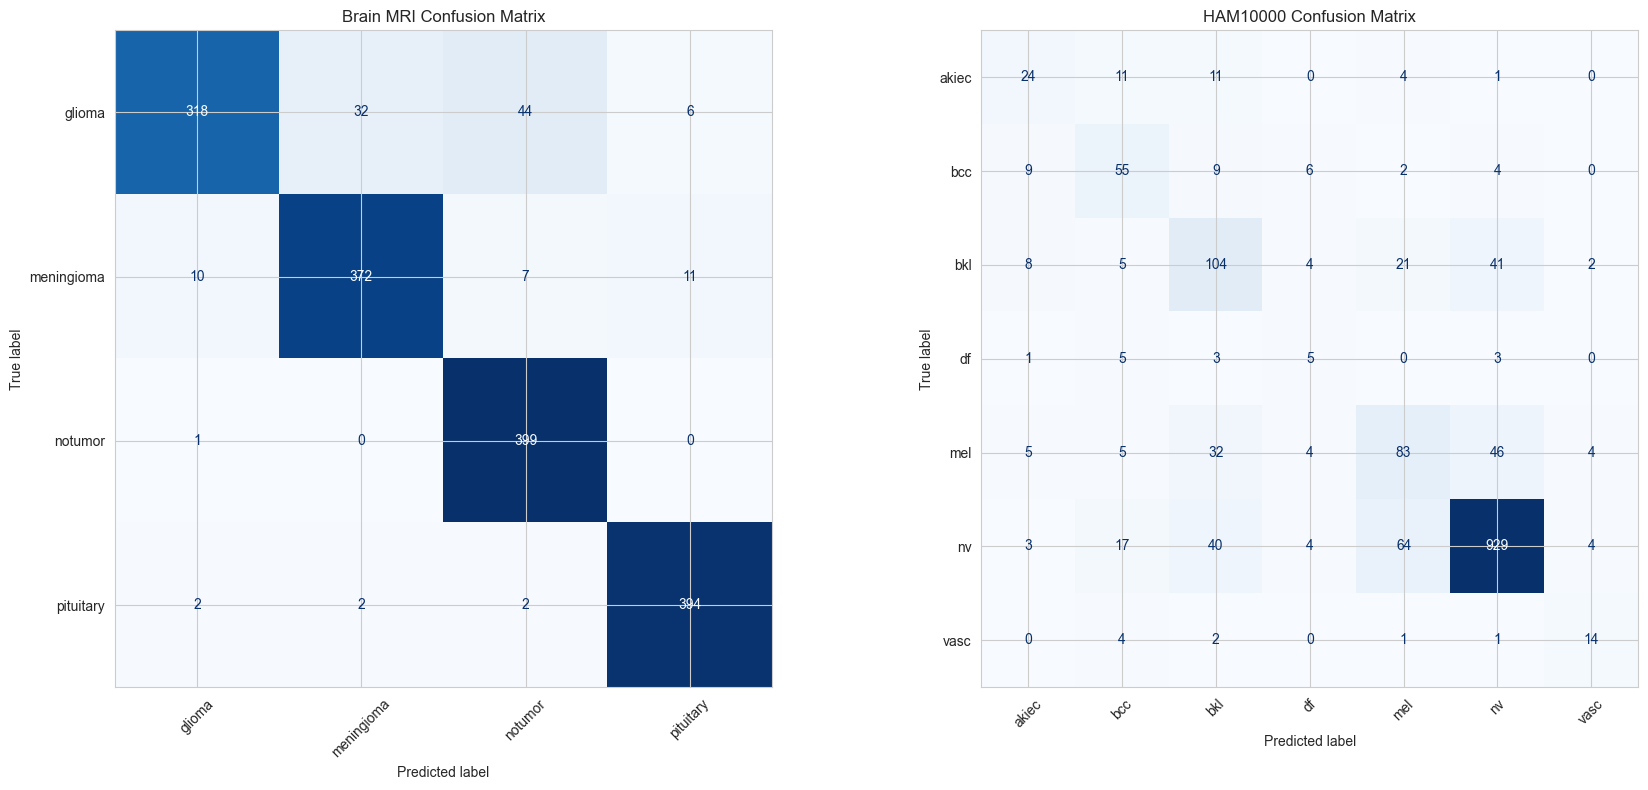

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

brain_class_names = ["glioma", "meningioma", "notumor", "pituitary"]
ham_class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

cm_brain = confusion_matrix(y_true_labels1, y_pred_labels1)
ConfusionMatrixDisplay(cm_brain, display_labels=brain_class_names).plot(
    ax=axes[0], cmap="Blues", xticks_rotation=45, colorbar=False
)
axes[0].set_title("Brain MRI Confusion Matrix")

cm_ham = confusion_matrix(y_true_labels2, y_pred_labels2)
ConfusionMatrixDisplay(cm_ham, display_labels=ham_class_names).plot(
    ax=axes[1], cmap="Blues", xticks_rotation=45, colorbar=False
)
axes[1].set_title("HAM10000 Confusion Matrix")

plt.tight_layout()
plt.show()
